In [1]:
!pip install torchinfo
!pip install --quiet torchview graphviz

In [11]:
import math
import os
import time
from datetime import timedelta
import random

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
from IPython.display import SVG, display

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from torchinfo import summary
from torchview import draw_graph

import torchvision.models as models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
ROOT_DIR = '/kaggle/input/competitions/aptos2019-blindness-detection'
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 4
RANDOM_STATE = 42

In [13]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

ROOT_DIR = "/kaggle/input/competitions/aptos2019-blindness-detection"   # change if needed


# =========================
# APTOS CSV LOADER
# =========================
def load_aptos_annotations(root_dir,
                           csv_name="train.csv",
                           image_folder="train_images"):
    """
    Load APTOS 2019 annotations from train.csv
    
    Returns dataframe with:
    image_path | label
    """

    csv_path = os.path.join(root_dir, csv_name)

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"{csv_path} not found")

    df = pd.read_csv(csv_path)

    required_cols = ["id_code", "diagnosis"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    records = []
    missing_images = 0

    for _, row in df.iterrows():
        img_id = str(row["id_code"]).strip()
        label = int(row["diagnosis"])

        img_path = os.path.join(root_dir, image_folder, img_id + ".png")

        if os.path.isfile(img_path):
            records.append((img_path, label))
        else:
            missing_images += 1

    df_records = pd.DataFrame(records, columns=["image_path", "label"])

    print("========== DATA SUMMARY ==========")
    print("Loaded images:", len(df_records))
    print("Missing images:", missing_images)
    print("Class distribution:")
    print(df_records["label"].value_counts().sort_index())
    print("==================================")

    return df_records


# =========================
# LOAD DATA
# =========================
df_all = load_aptos_annotations(ROOT_DIR)


# =========================
# CLASSES (APTOS = 5)
# =========================
CLASSES = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

num_classes = len(CLASSES)


# =========================
# TRAIN / VAL / TEST SPLIT
# =========================
train_df, temp_df = train_test_split(
    df_all,
    test_size=0.30,
    stratify=df_all["label"],
    random_state=RANDOM_STATE
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_STATE
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

========== DATA SUMMARY ==========
Loaded images: 3662
Missing images: 0
Class distribution:
label
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Split sizes:
Train: 2563
Val: 549
Test: 550


In [14]:
def print_split_stats(train_df, val_df, test_df, classes=None):

    def count_per_class(df):
        return df['label'].value_counts().sort_index()

    train_counts = count_per_class(train_df)
    val_counts = count_per_class(val_df)
    test_counts = count_per_class(test_df)

    all_classes = sorted(set(train_counts.index)
                         .union(val_counts.index)
                         .union(test_counts.index))

    summary = pd.DataFrame(index=all_classes)
    summary['Train_count'] = train_counts
    summary['Val_count'] = val_counts
    summary['Test_count'] = test_counts

    summary = summary.fillna(0).astype(int)
    summary['Total'] = summary.sum(axis=1)

    # avoid divide-by-zero
    summary['Train_pct'] = summary.apply(
        lambda r: (r['Train_count']/r['Total']*100) if r['Total'] else 0, axis=1)
    summary['Val_pct'] = summary.apply(
        lambda r: (r['Val_count']/r['Total']*100) if r['Total'] else 0, axis=1)
    summary['Test_pct'] = summary.apply(
        lambda r: (r['Test_count']/r['Total']*100) if r['Total'] else 0, axis=1)

    print(f"{'Class':<20}{'Train':>14}{'Val':>14}{'Test':>14}{'Total':>10}")
    print("-" * 75)

    for idx, row in summary.iterrows():

        if classes and isinstance(idx, int) and idx < len(classes):
            class_name = classes[idx]
        else:
            class_name = f"Class {idx}"

        print(f"{class_name:<20}"
              f"{row['Train_count']:>5} ({row['Train_pct']:>6.2f}%)"
              f"{row['Val_count']:>6} ({row['Val_pct']:>6.2f}%)"
              f"{row['Test_count']:>6} ({row['Test_pct']:>6.2f}%)"
              f"{row['Total']:>8}")

    total_train = len(train_df)
    total_val = len(val_df)
    total_test = len(test_df)
    total_all = total_train + total_val + total_test

    print("-" * 75)
    print(f"{'Total':<20}"
          f"{total_train:>5} ({100*total_train/total_all:>6.2f}%)"
          f"{total_val:>6} ({100*total_val/total_all:>6.2f}%)"
          f"{total_test:>6} ({100*total_test/total_all:>6.2f}%)"
          f"{total_all:>8}")

print_split_stats(train_df, val_df, test_df, classes=CLASSES)

Class                        Train           Val          Test     Total
---------------------------------------------------------------------------
No DR               1263.0 ( 69.97%) 271.0 ( 15.01%) 271.0 ( 15.01%)  1805.0
Mild                259.0 ( 70.00%)  55.0 ( 14.86%)  56.0 ( 15.14%)   370.0
Moderate            699.0 ( 69.97%) 150.0 ( 15.02%) 150.0 ( 15.02%)   999.0
Severe              135.0 ( 69.95%)  29.0 ( 15.03%)  29.0 ( 15.03%)   193.0
Proliferative DR    207.0 ( 70.17%)  44.0 ( 14.92%)  44.0 ( 14.92%)   295.0
---------------------------------------------------------------------------
Total                2563 ( 69.99%)   549 ( 14.99%)   550 ( 15.02%)    3662


In [15]:
# Dataset class
class AptosDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'label']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


# Transforms
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# Datasets and loaders
train_dataset = AptosDataset(train_df, transform=transform)
val_dataset = AptosDataset(val_df, transform=transform)
test_dataset = AptosDataset(test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

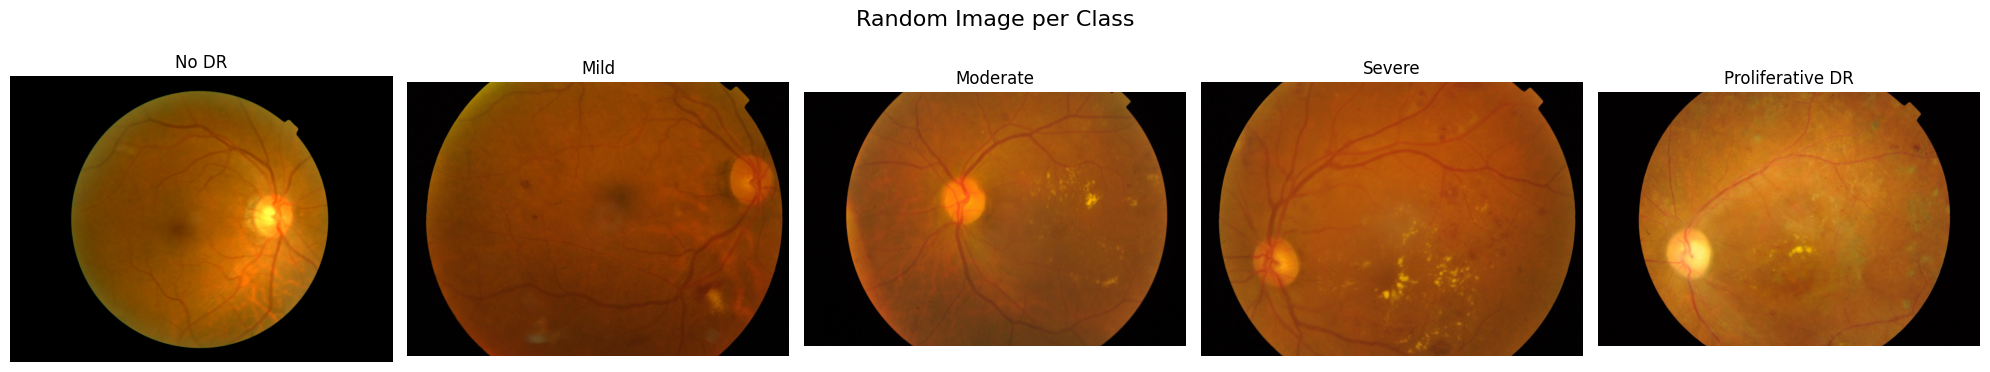

In [16]:
def show_random_images_per_class(df, classes, title="Random Image per Class"):
    num_classes = len(classes)
    fig, axs = plt.subplots(1, num_classes, figsize=(4 * num_classes, 4))
    if num_classes == 1:
        axs = [axs]

    for i, cls in enumerate(range(num_classes)):
        class_df = df[df['label'] == cls]
        if len(class_df) == 0:
            axs[i].axis("off")
            axs[i].set_title(f"{classes[cls]}\n(No Images)")
            continue

        row = class_df.sample(n=1).iloc[0]
        image = Image.open(row['image_path']).convert('RGB')
        axs[i].imshow(image)
        axs[i].set_title(classes[cls], fontsize=12)
        axs[i].axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()
show_random_images_per_class(train_df, CLASSES)

In [46]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import torch.nn as nn
import torch

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(CLASSES)

# Load pretrained ConvNeXt-Tiny
model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)

# Get input features of classifier
in_features = model.classifier[2].in_features

# Replace classifier
model.classifier[2] = nn.Linear(in_features, num_classes)

# Move to device
model = model.to(device)

# Summary
from torchinfo import summary
summary(model, input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"])

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 236MB/s] 


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
ConvNeXt                                      [1, 3, 224, 224]          [1, 5]                    --                        True
├─Sequential: 1-1                             [1, 3, 224, 224]          [1, 768, 7, 7]            --                        True
│    └─Conv2dNormActivation: 2-1              [1, 3, 224, 224]          [1, 96, 56, 56]           --                        True
│    │    └─Conv2d: 3-1                       [1, 3, 224, 224]          [1, 96, 56, 56]           4,704                     True
│    │    └─LayerNorm2d: 3-2                  [1, 96, 56, 56]           [1, 96, 56, 56]           192                       True
│    └─Sequential: 2-2                        [1, 96, 56, 56]           [1, 96, 56, 56]           --                        True
│    │    └─CNBlock: 3-3                      [1, 96, 56, 56]           [1, 96, 56, 56]     

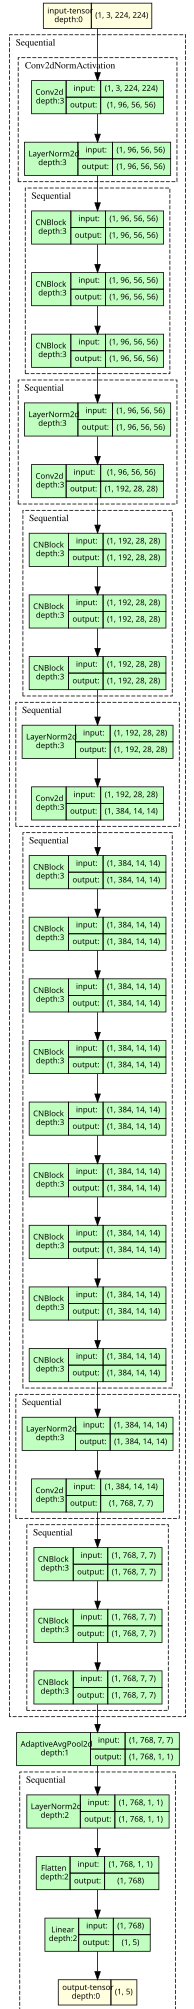

In [47]:
# Dummy input (can adjust shape based on your model's expected input)
dummy_input = torch.randn(1, 3, 224, 224, device=device)

# Generate the graph — expand_nested=True if model has nested submodules
model_graph = draw_graph(
    model,
    input_data=dummy_input,
    expand_nested=True,
    save_graph=False  # We don't want to save, only display inline
)

# Render to SVG and display inline in the notebook
svg_output = model_graph.visual_graph.pipe(format='svg')
display(SVG(svg_output))

In [49]:
def custom_metrics(y_pred, y_true, loss):
    y_pred_classes = torch.argmax(y_pred, dim=1)

    y_true_numpy = y_true.cpu().numpy()
    y_pred_classes_numpy = y_pred_classes.cpu().numpy()

    accuracy = accuracy_score(y_true_numpy, y_pred_classes_numpy)

    precision = precision_score(
        y_true_numpy, y_pred_classes_numpy,
        average='weighted', zero_division=0
    )

    recall = recall_score(
        y_true_numpy, y_pred_classes_numpy,
        average='weighted', zero_division=0
    )

    f1 = f1_score(
        y_true_numpy, y_pred_classes_numpy,
        average='weighted', zero_division=0
    )

    num_classes = y_pred.shape[1]
    auc_scores = []

    for class_idx in range(num_classes):
        class_y_true = (y_true_numpy == class_idx).astype(np.float32)
        class_y_pred = y_pred[:, class_idx].cpu().numpy()

        if np.unique(class_y_true).size < 2:
            continue

        try:
            auc_score = roc_auc_score(class_y_true, class_y_pred)
            auc_scores.append(auc_score)
        except ValueError:
            continue

    auc_avg = np.mean(auc_scores) if auc_scores else 0.0

    metrics = {
        "loss": loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc": auc_avg,
    }

    return metrics

In [50]:
# Hyperparameters
num_epochs = 30
initial_lr = 0.0006

# Criterion, optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=initial_lr)

# Plateau LR scheduler (fixed — no verbose arg)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.75,
    patience=5
)

# Early Stopping parameters
early_stopping_patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False

In [51]:
# Metrics initialization
metric_names = ["loss", "accuracy", "precision", "recall", "f1_score", "auc"]

train_metrics_history = {metric: [] for metric in metric_names}
val_metrics_history = {metric: [] for metric in metric_names}

best_val_loss = float("inf")

# Early Stopping
early_stopping_patience = 5
epochs_no_improve = 0
early_stop = False


# Training and validation loop
for epoch in range(num_epochs):

    # ===== TRAIN =====
    model.train()
    total_train_loss = 0.0
    all_train_predictions = []
    all_train_targets = []

    for data, targets in tqdm(train_loader, desc=f"Training Epoch [{epoch+1}/{num_epochs}]"):
        data = data.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        all_train_predictions.extend(outputs.detach().cpu().numpy())
        all_train_targets.extend(targets.detach().cpu().numpy())

    avg_train_loss = total_train_loss / len(train_loader)

    train_metrics = custom_metrics(
        torch.tensor(np.array(all_train_predictions)),
        torch.tensor(np.array(all_train_targets)),
        avg_train_loss
    )

    print("Train Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in train_metrics.items()]))

    for metric in metric_names:
        train_metrics_history[metric].append(train_metrics[metric])


    # ===== VALIDATION =====
    model.eval()
    total_val_loss = 0.0
    all_val_predictions = []
    all_val_targets = []

    with torch.no_grad():
        for data, targets in tqdm(val_loader, desc="Validating Model"):
            data = data.to(device)
            targets = targets.to(device)

            outputs = model(data)
            loss = criterion(outputs, targets)

            total_val_loss += loss.item()
            all_val_predictions.extend(outputs.detach().cpu().numpy())
            all_val_targets.extend(targets.detach().cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)

    val_metrics = custom_metrics(
        torch.tensor(np.array(all_val_predictions)),
        torch.tensor(np.array(all_val_targets)),
        avg_val_loss
    )

    print("Val Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in val_metrics.items()]))

    for metric in metric_names:
        val_metrics_history[metric].append(val_metrics[metric])


    # ===== Save BEST model =====
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(),
                   "/kaggle/working/best_model_weights.pth")

        torch.save(model,
                   "/kaggle/working/best_model_full.pth")

        print("✅ Best model saved")

    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")


    # ===== Scheduler =====
    scheduler.step(avg_val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{num_epochs} — ValLoss: {avg_val_loss:.4f} — LR: {current_lr:.6f}")


    # ===== Early Stopping Check =====
    if epochs_no_improve >= early_stopping_patience:
        print("🛑 Early stopping triggered!")
        break

Training Epoch [1/30]: 100%|██████████| 161/161 [02:03<00:00,  1.30it/s]


Train Metrics - loss: 1.3208, accuracy: 0.4842, precision: 0.3131, recall: 0.4842, f1_score: 0.3348, auc: 0.4955


Validating Model: 100%|██████████| 35/35 [00:27<00:00,  1.29it/s]


Val Metrics - loss: 1.3024, accuracy: 0.4936, precision: 0.2437, recall: 0.4936, f1_score: 0.3263, auc: 0.5719
✅ Best model saved
Epoch 1/30 — ValLoss: 1.3024 — LR: 0.000600


Training Epoch [2/30]: 100%|██████████| 161/161 [02:03<00:00,  1.30it/s]


...

Val Metrics - loss: 0.9547, accuracy: 0.6576, precision: 0.5855, recall: 0.6576, f1_score: 0.5947, auc: 0.7703
No improvement for 4 epoch(s)
Epoch 15/30 — ValLoss: 0.9547 — LR: 0.000600


Training Epoch [16/30]: 100%|██████████| 161/161 [02:04<00:00,  1.29it/s]


Train Metrics - loss: 0.9042, accuracy: 0.6805, precision: 0.5953, recall: 0.6805, f1_score: 0.6138, auc: 0.7677


Validating Model: 100%|██████████| 35/35 [00:25<00:00,  1.38it/s]

Val Metrics - loss: 0.9483, accuracy: 0.6576, precision: 0.5855, recall: 0.6576, f1_score: 0.5947, auc: 0.7712
No improvement for 5 epoch(s)
Epoch 16/30 — ValLoss: 0.9483 — LR: 0.000600
🛑 Early stopping triggered!


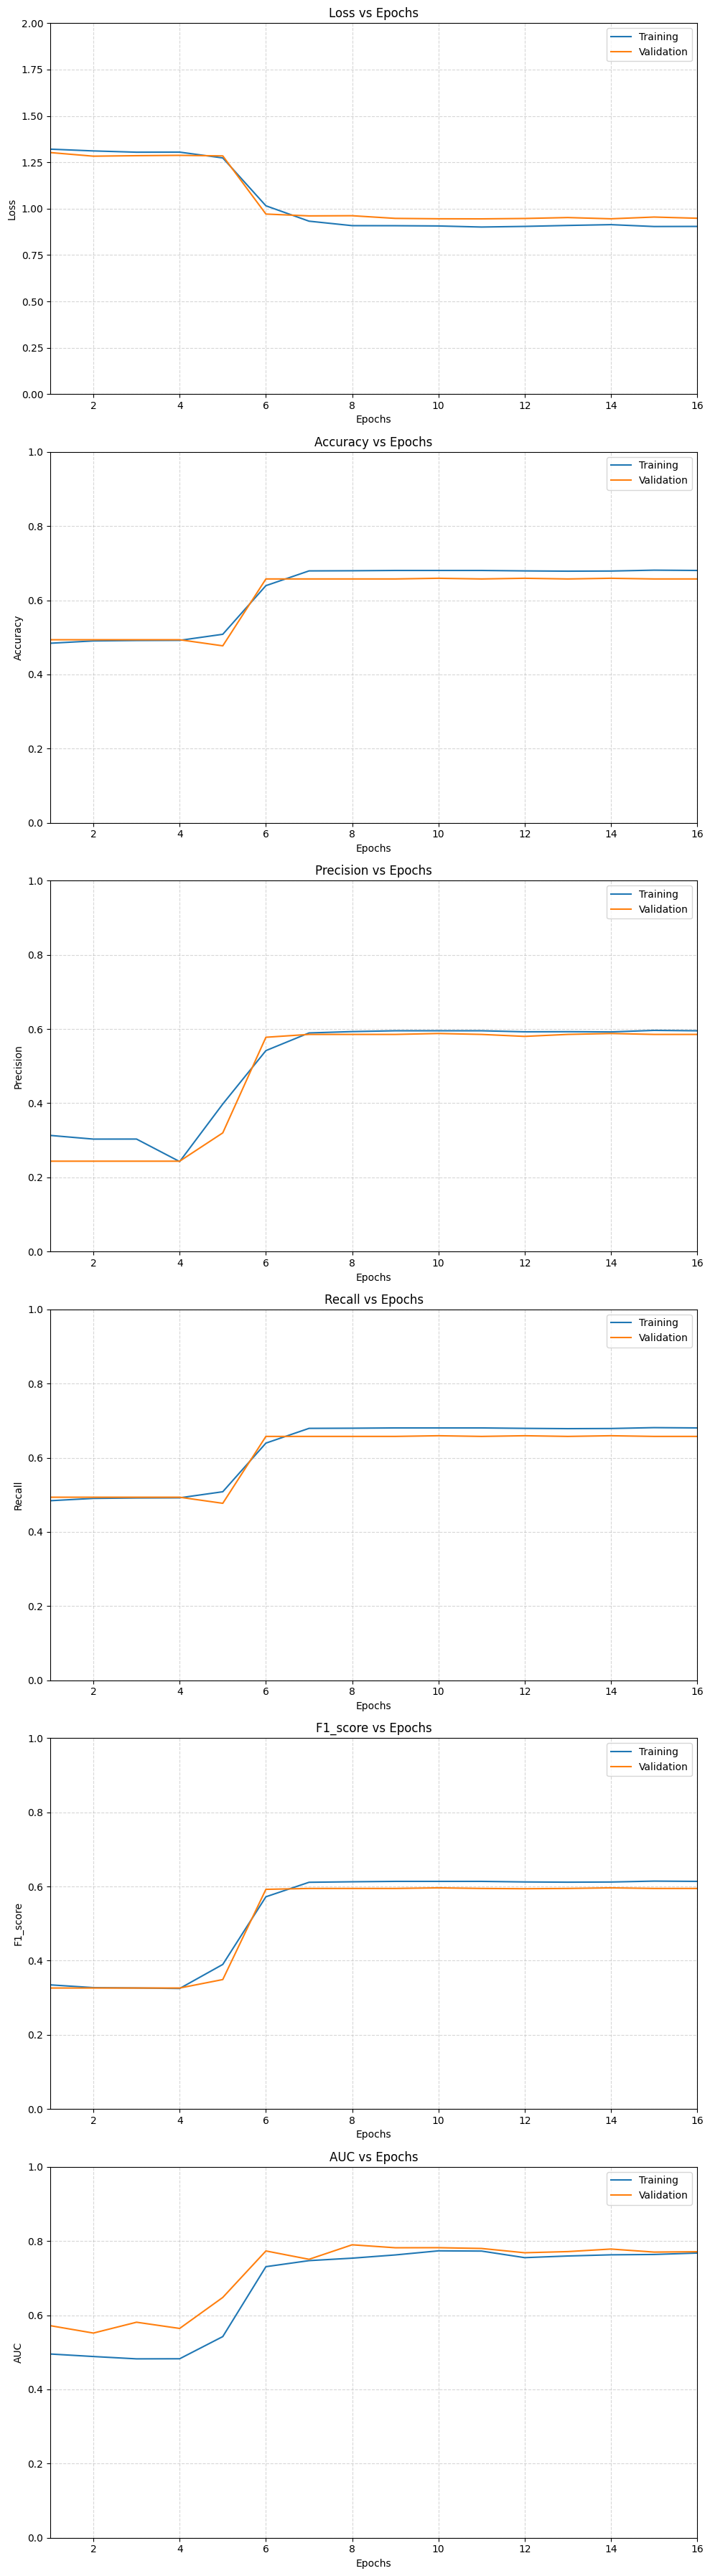

In [52]:
def plot_metrics(train_metrics_history, val_metrics_history, metric_names):
    num_metrics = len(metric_names)
    num_epochs = len(train_metrics_history[metric_names[0]])

    figure, axes = plt.subplots(num_metrics, figsize=(10, 6 * num_metrics))
    if num_metrics == 1:
        axes = [axes]

    rng = range(1, num_epochs + 1)

    for ax, metric_name in zip(axes, metric_names):
        train_metric = train_metrics_history[metric_name]
        val_metric = val_metrics_history[metric_name]

        ax.plot(rng, train_metric, label="Training")
        ax.plot(rng, val_metric, label="Validation")
        ax.legend()
        ax.set_xlabel("Epochs")

        if metric_name == "auc":
            ax.set_ylabel("AUC")
            ax.set_title("AUC vs Epochs")
        else:
            ax.set_ylabel(metric_name.capitalize())
            ax.set_title(f"{metric_name.capitalize()} vs Epochs")

        max_metric = max(max(train_metric), max(val_metric))
        min_metric = min(min(train_metric), min(val_metric))
        y_max = math.ceil(max_metric)

        if min_metric > 0 or max_metric > 1:
            ax.set_ylim(0, y_max)
        else:
            ax.set_ylim(min_metric, y_max)

        ax.grid(True, linestyle='--', alpha=0.5)

        if num_epochs == 1:
            ax.set_xlim(0.5, 1.5)
        else:
            ax.set_xlim(1, num_epochs)

    plt.tight_layout()
    plt.show()


plot_metrics(train_metrics_history, val_metrics_history, metric_names)

In [53]:
model = torch.load(
    "/kaggle/working/best_model_full.pth",
    map_location=device,
    weights_only=False   # ✅ FIX
)
model = model.to(device)
model.eval()

print("✅ Model loaded successfully")

✅ Model loaded successfully


In [54]:
# Testing loop
#model.eval()
total_test_loss = 0.0
all_test_predictions = []
all_test_targets = []

with torch.no_grad():
    for batch_idx, (data, targets) in enumerate(tqdm(test_loader, desc="Testing Model")):
        data = data.to(device)
        targets = targets.to(device)

        outputs = model(data)
        loss = criterion(outputs, targets)
        total_test_loss += loss.item()

        all_test_predictions.extend(outputs.detach().cpu().numpy())
        all_test_targets.extend(targets.detach().cpu().numpy())

all_test_predictions = np.array(all_test_predictions)
all_test_targets = np.array(all_test_targets)

average_test_loss = total_test_loss / len(test_loader)

test_metrics = custom_metrics(
    torch.tensor(all_test_predictions),
    torch.tensor(all_test_targets),
    average_test_loss
)

testing_metrics_line = "Test Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in test_metrics.items()])
print(testing_metrics_line)

Testing Model: 100%|██████████| 35/35 [00:26<00:00,  1.30it/s]

Test Metrics - loss: 0.8736, accuracy: 0.6945, precision: 0.6007, recall: 0.6945, f1_score: 0.6243, auc: 0.7838


In [55]:
true_labels = np.array(all_test_targets)
predicted_labels = np.argmax(np.array(all_test_predictions), axis=1)

true_labels = true_labels.astype(int)
predicted_labels = predicted_labels.astype(int)

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=CLASSES,
    digits=4
)

accuracy = accuracy_score(true_labels, predicted_labels)
num_errors = np.sum(true_labels != predicted_labels)

print(report)
print(f'There were {num_errors} errors in {len(predicted_labels)} tests for an accuracy of {accuracy * 100:6.2f}%')

                  precision    recall  f1-score   support

           No DR     0.9516    0.8708    0.9094       271
            Mild     0.0000    0.0000    0.0000        56
        Moderate     0.4834    0.9733    0.6460       150
          Severe     0.0000    0.0000    0.0000        29
Proliferative DR     0.0000    0.0000    0.0000        44

        accuracy                         0.6945       550
       macro avg     0.2870    0.3688    0.3111       550
    weighted avg     0.6007    0.6945    0.6243       550

There were 168 errors in 550 tests for an accuracy of  69.45%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
